# POS Tagging - An Overview

The process of classifying words into their __parts of speech__ and labeling them accordingly is known as **part-of-speech tagging**, or simply **POS-tagging**.

The NLTK library has a number of corpora which contains word and its POS tag. The following table provide information about each tag:

![POS tags](./jupyter resources/pos_tagging.png)

# Notebook layout
1. Preprocess data
2. Vanilla RNN
3. Word Embeddings
4. LSTM
5. GRU
6. Bidirectional LSTM
7. Model Evaluation

In [1]:
import numpy as np

from matplotlib import pyplot as plt

from nltk.corpus import brown
from nltk.corpus import treebank
from nltk.corpus import conll2000

import seaborn as sns

from gensim.models import KeyedVectors

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    TimeDistributed,
    LSTM,
    GRU,
    Bidirectional,
    SimpleRNN,
    RNN,
)
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [123]:
import nltk

corpus = conll2000.tagged_sents(tagset="universal")

In [124]:
len(corpus)

10948

In [125]:
corpus[0]

[('Confidence', 'NOUN'),
 ('in', 'ADP'),
 ('the', 'DET'),
 ('pound', 'NOUN'),
 ('is', 'VERB'),
 ('widely', 'ADV'),
 ('expected', 'VERB'),
 ('to', 'PRT'),
 ('take', 'VERB'),
 ('another', 'DET'),
 ('sharp', 'ADJ'),
 ('dive', 'NOUN'),
 ('if', 'ADP'),
 ('trade', 'NOUN'),
 ('figures', 'NOUN'),
 ('for', 'ADP'),
 ('September', 'NOUN'),
 (',', '.'),
 ('due', 'ADJ'),
 ('for', 'ADP'),
 ('release', 'NOUN'),
 ('tomorrow', 'NOUN'),
 (',', '.'),
 ('fail', 'VERB'),
 ('to', 'PRT'),
 ('show', 'VERB'),
 ('a', 'DET'),
 ('substantial', 'ADJ'),
 ('improvement', 'NOUN'),
 ('from', 'ADP'),
 ('July', 'NOUN'),
 ('and', 'CONJ'),
 ('August', 'NOUN'),
 ("'s", 'PRT'),
 ('near-record', 'ADJ'),
 ('deficits', 'NOUN'),
 ('.', '.')]

## Divide data in words (X) and tags (Y)

Since this is a **many-to-many** problem, each data point will be a different sentence of the corpora.

Each data point will have multiple words in the **input sequence**. This is what we will refer to as **X**.

Each word will have its correpsonding tag in the **output sequence**. This what we will refer to as **Y**.

Sample dataset:

|                    X                        |                 Y                |
|---------------------------------------------|----------------------------------|
|   Mr. Vinken is chairman of Elsevier        |   NOUN NOUN VERB NOUN ADP NOUN   |
|     We have no useful information           |      PRON VERB DET ADJ NOUN      |

In [126]:
X = []
Y = []


for sentence in corpus:
    X_sentence = []
    Y_sentence = []
    for entity in sentence:
        X_sentence.append(entity[0])  # entity[0] contains the word
        Y_sentence.append(entity[1])  # entity[1] contains corresponding tag

    X.append(X_sentence)
    Y.append(Y_sentence)

In [127]:
len(X)

10948

In [128]:
X[0], len(X[0])

(['Confidence',
  'in',
  'the',
  'pound',
  'is',
  'widely',
  'expected',
  'to',
  'take',
  'another',
  'sharp',
  'dive',
  'if',
  'trade',
  'figures',
  'for',
  'September',
  ',',
  'due',
  'for',
  'release',
  'tomorrow',
  ',',
  'fail',
  'to',
  'show',
  'a',
  'substantial',
  'improvement',
  'from',
  'July',
  'and',
  'August',
  "'s",
  'near-record',
  'deficits',
  '.'],
 37)

In [129]:
Y[0], len(Y[0])

(['NOUN',
  'ADP',
  'DET',
  'NOUN',
  'VERB',
  'ADV',
  'VERB',
  'PRT',
  'VERB',
  'DET',
  'ADJ',
  'NOUN',
  'ADP',
  'NOUN',
  'NOUN',
  'ADP',
  'NOUN',
  '.',
  'ADJ',
  'ADP',
  'NOUN',
  'NOUN',
  '.',
  'VERB',
  'PRT',
  'VERB',
  'DET',
  'ADJ',
  'NOUN',
  'ADP',
  'NOUN',
  'CONJ',
  'NOUN',
  'PRT',
  'ADJ',
  'NOUN',
  '.'],
 37)

In [130]:
len(Y)

10948

In [131]:
num_words = len(set([word.lower() for sentence in X for word in sentence]))
num_tags = len(set([word.lower() for sentence in Y for word in sentence]))

In [132]:
num_words

19460

In [133]:
num_tags

12

In [134]:
from collections import Counter

In [135]:
words

Counter({'posthumous': 1,
         'erythroid': 1,
         'install': 1,
         'sides': 1,
         'industries': 1,
         '687.87': 1,
         'responsibilities': 1,
         'deceiving': 1,
         'gear': 1,
         'railways': 1,
         'detergency': 1,
         'exhaled': 1,
         'task': 1,
         'flanders': 1,
         'extractor': 1,
         'variance': 1,
         "joel's": 1,
         'riddled': 1,
         "graves'": 1,
         'nut': 1,
         'differs': 1,
         'high-water': 1,
         'granulocytic': 1,
         'burst': 1,
         'inevitably': 1,
         '30-odd': 1,
         'garter': 1,
         'representatives': 1,
         'encourages': 1,
         'mezzo': 1,
         'couve': 1,
         'wanders': 1,
         'glamour': 1,
         'terramycin': 1,
         'scrupulosity': 1,
         'thatched-roof': 1,
         'boies': 1,
         '646': 1,
         'conveniences': 1,
         'high-class': 1,
         'transmissible': 1,
        

In [136]:
tags = set([a for sentence in Y for a in sentence])

In [137]:
len(tags)

12

## Dataset.. each sentence is assumed to be independent of another sentence..
### Meaning not an essay, but each sentence is an english sentence

In [138]:
print(" ".join(X[0]))

Confidence in the pound is widely expected to take another sharp dive if trade figures for September , due for release tomorrow , fail to show a substantial improvement from July and August 's near-record deficits .


In [139]:
print(X[0])

['Confidence', 'in', 'the', 'pound', 'is', 'widely', 'expected', 'to', 'take', 'another', 'sharp', 'dive', 'if', 'trade', 'figures', 'for', 'September', ',', 'due', 'for', 'release', 'tomorrow', ',', 'fail', 'to', 'show', 'a', 'substantial', 'improvement', 'from', 'July', 'and', 'August', "'s", 'near-record', 'deficits', '.']


In [140]:
len(X)

10948

In [141]:
vocabulary = list(
    set([word.lower() for sentence in X for word in sentence])
)  # Why set?

In [142]:
vocabulary[:10], len(vocabulary)

(['submit',
  'install',
  'drivers',
  'mid-season',
  'north-south',
  'sides',
  'industries',
  'symbolic',
  'responsibilities',
  'leeway'],
 19460)

In [143]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)

In [144]:
X_encoded = tokenizer.texts_to_sequences(X)

In [145]:
type(X_encoded)

list

In [146]:
len(X_encoded)

10948

In [147]:
print(X_encoded[0])

[1571, 7, 2, 1847, 15, 1088, 190, 5, 202, 242, 1089, 5757, 73, 378, 604, 9, 469, 1, 249, 9, 1645, 2736, 1, 4780, 5, 569, 6, 1258, 1366, 22, 727, 8, 503, 10, 7251, 7252, 3]


In [148]:
# encode Y

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)

In [149]:
print(Y_encoded[0], Y[0])

[1, 4, 5, 1, 2, 8, 2, 9, 2, 5, 6, 1, 4, 1, 1, 4, 1, 3, 6, 4, 1, 1, 3, 2, 9, 2, 5, 6, 1, 4, 1, 11, 1, 9, 6, 1, 3] ['NOUN', 'ADP', 'DET', 'NOUN', 'VERB', 'ADV', 'VERB', 'PRT', 'VERB', 'DET', 'ADJ', 'NOUN', 'ADP', 'NOUN', 'NOUN', 'ADP', 'NOUN', '.', 'ADJ', 'ADP', 'NOUN', 'NOUN', '.', 'VERB', 'PRT', 'VERB', 'DET', 'ADJ', 'NOUN', 'ADP', 'NOUN', 'CONJ', 'NOUN', 'PRT', 'ADJ', 'NOUN', '.']


In [150]:
len(X_encoded)

10948

In [48]:
len(X_encoded)

72202

In [151]:
check = [1 if (len(a) != len(b)) else 0 for a, b in zip(X_encoded, Y_encoded)]

In [152]:
sum(check)

0

In [153]:
len(check)

10948

In [154]:
assert all(check) == 0

## Pad sequences

The next step after encoding the data is to **define the sequence lengths**. As of now, the sentences present in the data are of various lengths. We need to either pad short sentences or truncate long sentences to a fixed length. This fixed length, however, is a **hyperparameter**.

In [155]:
lengths = [len(seq) for seq in X_encoded]
print("Length of longest sentence: {}".format(max(lengths)))

Length of longest sentence: 78


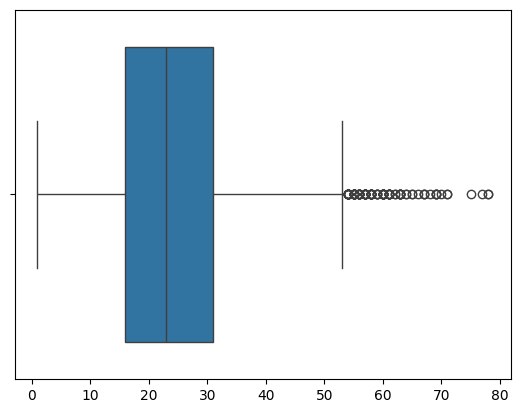

In [156]:
sns.boxplot(lengths, orient="y")
plt.show()

In [157]:
# Pad each sequence to MAX_SEQ_LENGTH using KERAS' pad_sequences() function.
# Sentences longer than MAX_SEQ_LENGTH are truncated.
# Sentences shorter than MAX_SEQ_LENGTH are padded with zeroes.

# Truncation and padding can either be 'pre' or 'post'.
# For padding we are using 'pre' padding type, that is, add zeroes on the left side.
# For truncation, we are using 'post', that is, truncate a sentence from right side.


MAX_LENGTH = 60
X_padded = pad_sequences(X_encoded, truncating="post", padding="pre", maxlen=MAX_LENGTH)

In [158]:
len(X_padded[0]), len(X_encoded[0]), len(X[0])

(60, 37, 37)

In [159]:
Y_padded = pad_sequences(Y_encoded, truncating="post", padding="pre", maxlen=MAX_LENGTH)

In [160]:
Y_padded[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  1,  4,  5,  1,  2,  8,  2,  9,  2,  5,  6,
        1,  4,  1,  1,  4,  1,  3,  6,  4,  1,  1,  3,  2,  9,  2,  5,  6,
        1,  4,  1, 11,  1,  9,  6,  1,  3], dtype=int32)

## Checking

In [54]:
sequence = [[1], [2, 3], [4, 5, 6]]
pad_sequences(sequence)

array([[0, 0, 1],
       [0, 2, 3],
       [4, 5, 6]], dtype=int32)

In [69]:
pad_sequences(sequence, padding="post", value=-1, truncating="post", maxlen=2)

array([[ 1, -1],
       [ 2,  3],
       [ 4,  5]], dtype=int32)

In [64]:
pad_sequences(sequence, padding="post", value=-1, truncating="pre", maxlen=2)

array([[ 1, -1],
       [ 2,  3],
       [ 5,  6]], dtype=int32)

In [71]:
a = pad_sequences(sequence, value=-1, truncating="pre", maxlen=2)

In [72]:
a.dtype

dtype('int32')

In [77]:
a

array([[-1,  1],
       [ 2,  3],
       [ 5,  6]], dtype=int32)

In [75]:
a1 = pad_sequences(sequence, value=-1, padding="pre", maxlen=2)

In [76]:
a1

array([[-1,  1],
       [ 2,  3],
       [ 5,  6]], dtype=int32)

## RNN will learn the zero to zero mapping while training. So we don't need to worry about the padded zeroes. Please note that zero is not reserved for any word or tag, it's only reserved for padding.

In [161]:
# assign padded sequences to X and Y
X_model, Y_model = X_padded, Y_padded

In [162]:
X = X_model.copy()
Y = Y_model.copy()

## Word embeddings

Currently, each word and each tag is encoded as an integer.

We'll use a more sophisticated technique to represent the input words (X) using what's known as **word embeddings**.

However, to represent each tag in Y, we'll simply use **one-hot encoding** scheme since there are only 13 tags in the dataset and the LSTM will have no problems in learning its own representation of these tags.

To use word embeddings, you can go for either of the following models:
1. word2vec model: https://code.google.com/archive/p/word2vec/
2. GloVe model : https://nlp.stanford.edu/projects/glove/

We're using the word2vec model for no particular reason. Both of these are very efficient in representing words. You can try both and see which one works better.

Dimensions of a word embedding is: (VOCABULARY_SIZE, EMBEDDING_DIMENSION)

In [163]:
file = "data/GoogleNews-vectors-negative300.bin"

In [164]:
model = KeyedVectors.load_word2vec_format(file, binary=True)

In [165]:
a = model.most_similar(positive=["King", "Queen"], negative="Man")

In [166]:
len(tokenizer.word_index)

19460

In [167]:
tokenizer.word_index["the"]

2

In [168]:
len(tokenizer.word_index)

19460

In [169]:
len(vocabulary)

19460

In [170]:
# assign word vectors from word2vec model

EMBEDDING_SIZE = (
    300  # each word in word2vec model is represented using a 300 dimensional vector
)

VOCABULARY_SIZE = len(vocabulary) + 1

embedding_weights = np.zeros((VOCABULARY_SIZE, EMBEDDING_SIZE))

In [171]:
embedding_weights

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [172]:
tokenizer.word_index["the"]

2

In [74]:
x = model[tokenizer.index_word[1]]

In [75]:
x.shape

(300,)

In [173]:
word_index = tokenizer.word_index

In [175]:
print(list(word_index.items())[:4])

[(',', 1), ('the', 2), ('.', 3), ('of', 4)]


In [176]:
try:
    for word, i in word_index.items():
        embedding_weights[i, :] = word_index[word]
except KeyError as e:
    pass

In [177]:
print("Embeddings shape: {}".format(embedding_weights.shape))

Embeddings shape: (19461, 300)


In [178]:
embedding_weights

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [2.0000e+00, 2.0000e+00, 2.0000e+00, ..., 2.0000e+00, 2.0000e+00,
        2.0000e+00],
       ...,
       [1.9458e+04, 1.9458e+04, 1.9458e+04, ..., 1.9458e+04, 1.9458e+04,
        1.9458e+04],
       [1.9459e+04, 1.9459e+04, 1.9459e+04, ..., 1.9459e+04, 1.9459e+04,
        1.9459e+04],
       [1.9460e+04, 1.9460e+04, 1.9460e+04, ..., 1.9460e+04, 1.9460e+04,
        1.9460e+04]])

array([[    0,     0,     0, ...,  7251,  7252,     3],
       [    0,     0,     0, ...,   250,   130,     3],
       [    0,     0,     0, ...,    81,   941,     3],
       ...,
       [    0,     0,     0, ...,   142,   310,     3],
       [    0,     0,     0, ...,    40,   247,     3],
       [    0,     0,     0, ...,    27, 10189,     3]], dtype=int32)

In [182]:
# embedding_weights[tokenizer.word_index[1]]

KeyError: 1

## building the RNN model.

**We're going to use word embeddings to represent the words. Now, while training the model, you can also train the word embeddings along with the network weights. These are often called the embedding weights. While training, the embedding weights will be treated as normal weights of the network which are updated in each iteration.**



In the next few sections, we will try the following three RNN models:

**RNN with arbitrarily initialised, untrainable embeddings: In this model, we will initialise the embedding weights arbitrarily. Further, we'll freeze the embeddings, that is, we won't allow the network to train them.**
 **RNN with arbitrarily initialised, trainable embeddings: In this model, we'll allow the network to train the embeddings.**
 **RNN with trainable word2vec embeddings: In this experiment, we'll use word2vec word embeddings and also allow the network to train them further.**

In [183]:
Y_model = to_categorical(Y_model)

In [186]:
Y_model[:3]

array([[[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [187]:
TEST_SIZE = 0.15
X_train, X_test, Y_train, Y_test = train_test_split(
    X_model, Y_model, test_size=TEST_SIZE, random_state=42
)

In [188]:
# split training data into training and validation sets
VALID_SIZE = 0.15
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X_train, Y_train, test_size=VALID_SIZE, random_state=42
)

In [189]:
# print number of samples in each set
print("TRAINING DATA")
print("Shape of input sequences: {}".format(X_train.shape))
print("Shape of output sequences: {}".format(Y_train.shape))
print("-" * 50)
print("VALIDATION DATA")
print("Shape of input sequences: {}".format(X_validation.shape))
print("Shape of output sequences: {}".format(Y_validation.shape))
print("-" * 50)
print("TESTING DATA")
print("Shape of input sequences: {}".format(X_test.shape))
print("Shape of output sequences: {}".format(Y_test.shape))

TRAINING DATA
Shape of input sequences: (7909, 60)
Shape of output sequences: (7909, 60, 13)
--------------------------------------------------
VALIDATION DATA
Shape of input sequences: (1396, 60)
Shape of output sequences: (1396, 60, 13)
--------------------------------------------------
TESTING DATA
Shape of input sequences: (1643, 60)
Shape of output sequences: (1643, 60, 13)


Before using RNN, we must make sure the dimensions of the data are what an RNN expects. In general, an RNN expects the following shape

Shape of X:
(#samples, #timesteps, #features)

Shape of Y:
(#samples, #timesteps, #features)

![RNN tensor shape](./jupyter resources/rnn_tensor.png)

Now, there can be various variations in the shape that you use to feed an RNN depending on the type of architecture. Since the problem we're working on has a many-to-many architecture, the input and the output both include number of timesteps which is nothing but the sequence length.

But notice that the tensor X doesn't have the third dimension, that is, number of features. That's because we're going to use word embeddings before feeding in the data to an RNN, and hence there is no need to explicitly mention the third dimension.

That's because when you use the Embedding() layer in Keras, you the training data will automatically be converted to (#samples, #timesteps, #features) where #features will be the embedding dimension (and note that the Embedding layer is always the very first layer of an RNN).

While using the embedding layer we only need to reshape the data to (#samples, #timesteps) which is what we have done. However, note that you'll need to shape it to (#samples, #timesteps, #features) in case you don't use the Embedding() layer in Keras.

# 2. Vanilla RNN

### Uninitialised fixed embeddings
First let's try running a vanilla RNN. For this RNN we won't use the pre-trained word embeddings. We'll use randomly inititalised embeddings. Moreover, we won't update the embeddings weights.

In [190]:
print(X_train[2])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0   722 11461 11462     1  2481   151     9  2800
    20     2  1390     7  3366  1076     1   494    67    13   992    99
   115  1356     2 11463    70     2  3132    29   615   200   146   245]


In [191]:
type(X_train)

numpy.ndarray

In [192]:
print(Y_model.shape[-1])

13


In [193]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,  # vocabulary size - number of unique words in data
        output_dim=EMBEDDING_SIZE,  # length of vector with which each word is represented
        input_length=MAX_LENGTH,  # length of input sequence
        trainable=False,  # False - don't update the embeddings)
    )
)

/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [194]:
rnn_model.add(SimpleRNN(units=64, return_sequences=True, name="vanilla_rnn"))

In [195]:
rnn_model.add(TimeDistributed(Dense(Y_model.shape[-1], activation="softmax")))

In [196]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn (SimpleRNN)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [197]:
rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [198]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_rnn (SimpleRNN)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Fitting the model

In [109]:
X_train.shape

(42959, 100)

In [199]:
rnn_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
    verbose=1,
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 61s 933ms/step - acc: 0.6625 - loss: 1.2318 - val_acc: 0.7182 - val_loss: 0.8954
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 928ms/step - acc: 0.7177 - loss: 0.8610 - val_acc: 0.7342 - val_loss: 0.8068
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 929ms/step - acc: 0.7568 - loss: 0.7780 - val_acc: 0.7750 - val_loss: 0.7232
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 935ms/step - acc: 0.7850 - loss: 0.6940 - val_acc: 0.8001 - val_loss: 0.6418
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 939ms/step - acc: 0.8127 - loss: 0.6169 - val_acc: 0.8310 - val_loss: 0.5714
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 900ms/step - acc: 0.8344 - loss: 0.5534 - val_acc: 0.8470 - val_loss: 0.5163
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 901ms/step - acc: 0.8488 - loss: 0.5030 - val_acc: 0.8605 - val_loss: 0.4716
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 908ms/step - acc: 0.8626 - loss: 0.4620 - val_acc: 0.8719 - val_loss: 0.4355
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 57s 922ms/